In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from attribscope.classifier.classifier import (
    MLPClassifier,
    train, infer, quick_eval,
    seed_everything
)
from attribscope.svd2.utils import (
    load_representations,
    _resolve_dir,
    split_data,
    compute_metrics,
    get_mistake_meta
)
import torch
from pathlib import Path

In [3]:
REPS_ROOT:    Path = Path("/data/hoang/attrib/outputs")
DATA_ROOT:    Path = Path("data/ww")
OUTPUTS_ROOT: Path = None

MODEL:        str   = ["llama-3.1-8b", "qwen3-8b"][0] 
SUBSET:       str   = ["algorithm-generated", "hand-crafted"][1] 
REP_TYPE:     str   = ["grads", "hidden"][1]  
POOLING:      str   = ["grad", "mean", "last"][1]   # grads -> grad, hidden -> last | mean
WEIGHT_NAMES: str | list[str] = "all"
LOSS:         str   = "ntp"   
TEMPERATURE:  float | None = None

RATIO:        float = 0.5
SEED:         int   = 10
DEVICE: torch.device = torch.device("cuda:7")

In [4]:
rep_dir = _resolve_dir(
    root_dir=REPS_ROOT, 
    model=MODEL, 
    subset=SUBSET,
    rep_type=REP_TYPE, 
    loss=LOSS, 
    temperature=TEMPERATURE,
    dir_type="representations"
)
data_dir = DATA_ROOT / SUBSET

print(f"Representation dir: {rep_dir}")
print(f"Data dir:           {data_dir}")

files = sorted(rep_dir.glob("*.safetensors"), key=lambda x: int(x.stem))
assert files, (f"No .safetensors files in {rep_dir}")
train_files, test_files = split_data(files, RATIO, SEED)
print(f"Total train trajectories: {len(train_files)}")
print(f"Total test trajectories:  {len(test_files)}")


Representation dir: /data/hoang/attrib/outputs/hidden/llama-3.1-8b/reps/hand-crafted
Data dir:           data/ww/hand-crafted
Total train trajectories: 29
Total test trajectories:  29


In [5]:
train_reps = load_representations(
    rep_dir=rep_dir,
    data_dir=data_dir,
    pooling=POOLING,
    weight_names=WEIGHT_NAMES,
    device=DEVICE,
    files=train_files,
)
test_reps = load_representations(
    rep_dir=rep_dir,
    data_dir=data_dir,
    pooling=POOLING,
    weight_names=WEIGHT_NAMES,
    device=DEVICE,
    files=test_files,
)

Loading representations:   0%|          | 0/29 [00:00<?, ?it/s]

Loading representations: 100%|██████████| 29/29 [00:03<00:00,  8.52it/s]


In [ ]:
import re
def sort_key(s):
    if s == 'embed': return (-1, 0, '')
    match = re.search(r'(\d+)', s)
    num = int(match.group(1))
    return (0, num, s)

layer_idxs = list(train_reps.stores.keys())
layer_idxs = sorted(layer_idxs, key=sort_key)
LAYER_IDX  = layer_idxs[31]
print(f"Layers: {layer_idxs}\n")
print(f"Selected layer: {LAYER_IDX}")

Layers: ['embed', 'act/0', 'act/1', 'act/2', 'act/3', 'act/4', 'act/5', 'act/6', 'act/7', 'act/8', 'act/9', 'act/10', 'act/11', 'act/12', 'act/13', 'act/14', 'act/15', 'act/16', 'act/17', 'act/18', 'act/19', 'act/20', 'act/21', 'act/22', 'act/23', 'act/24', 'act/25', 'act/26', 'act/27', 'act/28', 'act/29', 'act/30', 'act/31', 'act/31_normed']

Selected layer: act/30


In [7]:
def downsample(X: torch.Tensor, y: torch.Tensor, weight: int = 1):
    """
    Undersample label 0 so that n(label 0) / n(label 1) = weight.
    All label 1 samples are kept.
    """
    idx_pos = (y == 1).nonzero(as_tuple=True)[0]
    idx_neg = (y == 0).nonzero(as_tuple=True)[0]

    n_neg_keep = min(len(idx_pos) * weight, len(idx_neg))
    idx_neg_sampled = idx_neg[torch.randperm(len(idx_neg))[:n_neg_keep]]

    idx_all = torch.cat([idx_pos, idx_neg_sampled])
    idx_all = idx_all[torch.randperm(len(idx_all))]  # shuffle

    return X[idx_all], y[idx_all]


def upsample(X: torch.Tensor, y: torch.Tensor, weight: int = 1):
    """
    Upsample label 1 (with replacement) so that n(label 0) / n(label 1) = weight.
    All label 0 samples are kept. If the current ratio is already <= weight,
    positives are left untouched (no downsampling of label 1).
    """
    idx_pos = (y == 1).nonzero(as_tuple=True)[0]
    idx_neg = (y == 0).nonzero(as_tuple=True)[0]

    n_pos_target = max(len(idx_neg) // weight, len(idx_pos))
    idx_pos_sampled = idx_pos[torch.randint(0, len(idx_pos), (n_pos_target,))]

    idx_all = torch.cat([idx_pos_sampled, idx_neg])
    idx_all = idx_all[torch.randperm(len(idx_all))]  # shuffle

    return X[idx_all], y[idx_all]

In [8]:
from attribscope.svd2.computation import (
    fit_all, score_all
)
svd = fit_all(train_reps.stores, n_components=10)

SVD fit: 100%|██████████| 34/34 [00:19<00:00,  1.79it/s]


In [10]:
import numpy as np
import matplotlib.pyplot as plt

def plot_dist(arr, title="Distribution", bins=50):
    arr = np.asarray(arr).flatten()
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(arr, bins=bins, alpha=0.6, edgecolor='black', linewidth=0.5)
    ax.axvline(np.mean(arr), color='red', linestyle='-', label=f'Mean: {np.mean(arr):.3f}')
    ax.axvline(np.median(arr), color='purple', linestyle='-', label=f'Median: {np.median(arr):.3f}')
    ax.set_title(title)
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")
    ax.legend()
    plt.tight_layout()
    plt.show()

In [17]:
roles = set([x.role for x in train_reps.keeper.index])
roles

{'Assistant',
 'ComputerTerminal',
 'FileSurfer',
 'Orchestrator (-> Assistant)',
 'Orchestrator (-> ComputerTerminal)',
 'Orchestrator (-> FileSurfer)',
 'Orchestrator (-> WebSurfer)',
 'Orchestrator (termination condition)',
 'Orchestrator (thought)',
 'WebSurfer'}

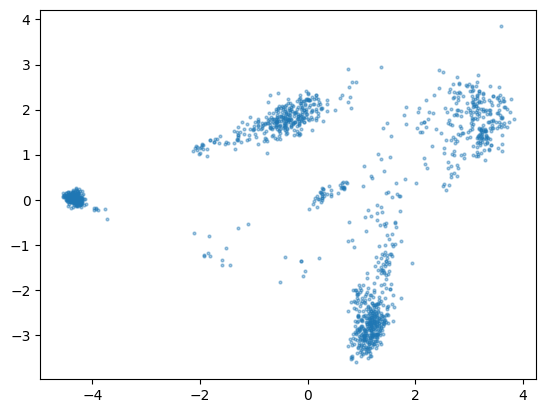

In [34]:
def standardize_role(role: str) -> str:
    if "Orchestrator (->" in role: 
        return "Orchestrator (-> Agent)"
    else: return role
roles = [standardize_role(x.role) for x in train_reps.keeper.index]
mistakes = [x.is_mistake for x in train_reps.keeper.index]

LAYER_IDX = 19
R = train_reps.stores[f'act/{LAYER_IDX}'].R
V = svd['mean'][f'act/{LAYER_IDX}']['V_centered'].to(R.device)
mean = svd['mean'][f'act/{LAYER_IDX}']['ref'].to(R.device)

Z = (R - mean) @ V[:, [0, 1]]
# Z = R.float() @ V[:, :2]
cosine_sim = torch.nn.functional.cosine_similarity(R - mean, V.T[0, :])

# plot_dist(cosine_sim.cpu().numpy(), title="Cosine Similarity Distribution")
plt.scatter(Z[:, 0].cpu(), Z[:, 1].cpu(), s=4, alpha=0.4)

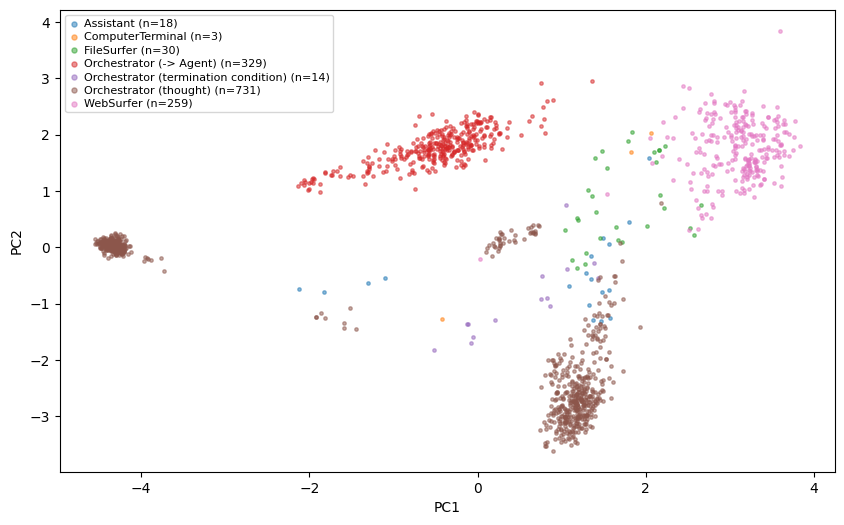

In [33]:
roles_arr = np.array(roles)
Z_cpu = Z.cpu().numpy()

fig, ax = plt.subplots(figsize=(10, 6))
for role in np.unique(roles_arr):
    mask = roles_arr == role
    ax.scatter(Z_cpu[mask, 0], Z_cpu[mask, 1],
               s=6, alpha=0.5, label=f"{role} (n={mask.sum()})")

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
# ax.legend(markerscale=2, loc="best")
ax.legend(
    fontsize=8,           # text size
    markerscale=1.5,      # legend marker size relative to plot markers
    handlelength=1,       # length of the marker line/symbol
    handletextpad=0.4,    # space between marker and text
    borderpad=0.3,        # padding inside the legend box
    labelspacing=0.3,     # vertical spacing between entries
    loc="best",
)
plt.show()

1384

In [135]:
n_components_score = list(range(1, 11))
score_kwargs = dict(
    svd=svd, 
    n_components_score=n_components_score, 
    device=DEVICE
)
scores = score_all(train_reps.stores,  **score_kwargs)

In [147]:
import pandas as pd
df = pd.DataFrame(scores)
df

,weight,pooling,method,c,centered,scores
0,act/0,mean,proj,1,True,"[0.00392, 0.000636, 0.01599, 0.0002271, 0.0030..."
1,act/0,mean,proj,2,True,"[0.003767, 0.0004005, 0.00808, 0.0001876, 0.00..."
2,act/0,mean,proj,3,True,"[0.003517, 0.0008817, 0.01005, 0.0006, 0.00303..."
3,act/0,mean,proj,4,True,"[0.003134, 0.0009575, 0.007668, 0.0006733, 0.0..."
4,act/0,mean,proj,5,True,"[0.002512, 0.001625, 0.006218, 0.00124, 0.0020..."
...,...,...,...,...,...,...
675,embed,mean,proj,6,False,"[0.004143, 0.003185, 0.004665, 0.003242, 0.003..."
676,embed,mean,proj,7,False,"[0.00356, 0.00289, 0.004036, 0.002897, 0.00306..."
677,embed,mean,proj,8,False,"[0.003134, 0.002542, 0.003534, 0.002548, 0.002..."
678,embed,mean,proj,9,False,"[0.00279, 0.002272, 0.003141, 0.002277, 0.0023..."


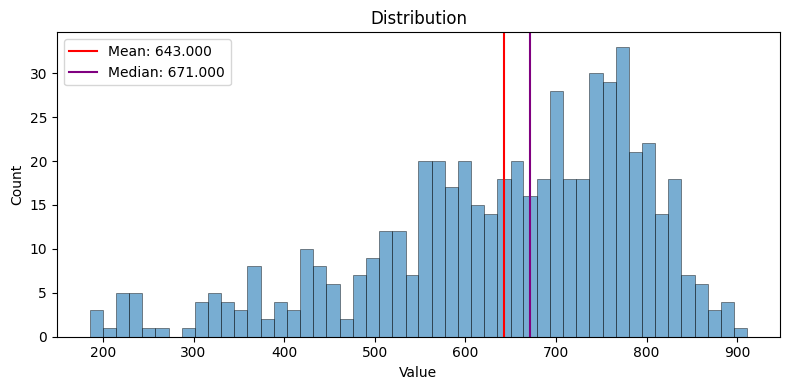

In [240]:
import numpy as np
import matplotlib.pyplot as plt

def plot_dist(arr, title="Distribution", bins=50):
    arr = np.asarray(arr).flatten()
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(arr, bins=bins, alpha=0.6, edgecolor='black', linewidth=0.5)
    ax.axvline(np.mean(arr), color='red', linestyle='-', label=f'Mean: {np.mean(arr):.3f}')
    ax.axvline(np.median(arr), color='purple', linestyle='-', label=f'Median: {np.median(arr):.3f}')
    ax.set_title(title)
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_dist(scores[490]['scores'])

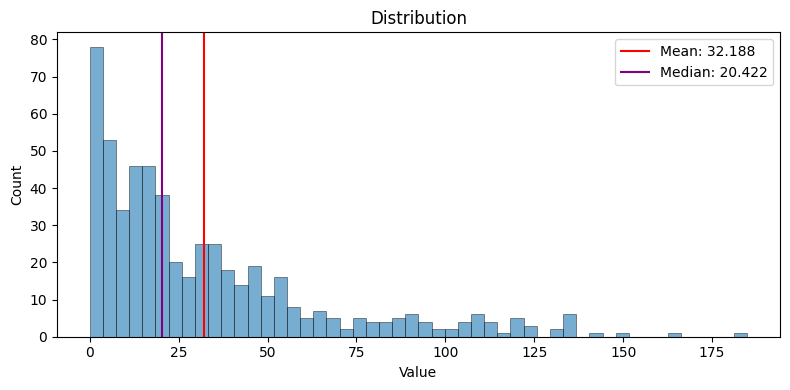

In [241]:
plot_dist(scores[480]['scores'])

In [235]:
scores[480]

{'weight': 'act/30',
 'pooling': 'mean',
 'method': 'proj',
 'c': 1,
 'centered': True,
 'scores': array([1.8193e+00, 1.1391e+01, 9.4312e+01, 5.7773e+00, 3.4188e+01,
        3.7781e+01, 1.3325e+02, 9.1309e-01, 1.5391e+01, 2.1141e+01,
        1.1312e+01, 5.7062e+01, 4.7500e+01, 1.8250e+01, 3.8906e+01,
        1.3109e+01, 8.1188e+01, 1.5527e+00, 1.8250e+01, 9.6953e+00,
        1.3969e+01, 6.4531e+00, 3.1688e+01, 9.5375e+01, 1.4883e+00,
        1.3562e+02, 7.7393e-01, 9.0000e+01, 2.8926e+00, 9.1562e+01,
        8.2080e-01, 8.1875e+01, 3.7781e-02, 9.1750e+01, 1.3164e+01,
        4.5875e+01, 2.2598e+00, 1.6672e+01, 3.6312e+01, 1.4719e+01,
        3.1763e-01, 1.8500e+01, 1.3406e+01, 6.6688e+01, 2.8223e+00,
        5.3031e+01, 1.6281e+01, 3.4625e+01, 1.6297e+01, 1.1475e+02,
        1.1562e+01, 4.9656e+01, 5.5195e+00, 3.0750e+01, 4.6469e+01,
        4.6688e+01, 3.2375e+01, 3.8500e+01, 4.9344e+01, 6.6062e+01,
        5.1523e+00, 2.2219e+01, 4.6211e+00, 2.6141e+01, 6.7041e-01,
        6.0562e+01

In [138]:
scores[0]['scores'].shape

(553,)

In [117]:
X_train = train_reps.stores[LAYER_IDX].R
y_train = torch.Tensor(
    [idx.is_mistake for idx in  train_reps.keeper.index],
).to(device=X_train.device)

X_test = test_reps.stores[LAYER_IDX].R
y_test = torch.Tensor(
    [idx.is_mistake for idx in  test_reps.keeper.index],
).to(device=X_test.device)

print("Before sampling:")
print(f"  train: {X_train.shape}, n={len(y_train)}, errors={y_train.mean():.1%}")
print(f"  test:  {X_test.shape}, n={len(y_test)}, errors={y_test.mean():.1%}")

if True:
    X_train, y_train = upsample(X_train, y_train, weight=1)
    print(f"After sampling\n  train: {X_train.shape}, n={len(y_train)}, errors={y_train.mean():.1%}")

Before sampling:
  train: torch.Size([553, 4096]), n=553, errors=11.4%
  test:  torch.Size([546, 4096]), n=546, errors=11.5%
After sampling
  train: torch.Size([980, 4096]), n=980, errors=50.0%


In [123]:
seed_everything()
clf, metrics = train(
    X = X_train,
    y = y_train,
    input_dim = X_train.shape[1],
    hidden_dim = 1024,
    seed = 42,
    epochs = 100,
    batch_size = 512,
    learning_rate = 0.05,
    weight_decay = 3e-4,
    momentum = 0.9,
    # pos_weight = None,
    logging_steps = 50,
    device = X_train.device
)

Epoch 50/100 - loss: 0.1253 | accuracy: 0.9704  | precision: 0.9441 | recall: 1.0000
Epoch 100/100 - loss: 0.0644 | accuracy: 0.9878  | precision: 0.9761 | recall: 1.0000


In [124]:
clf

MLPClassifier(
  (fc1): Linear(in_features=4096, out_features=1024, bias=True)
  (fc2): Linear(in_features=1024, out_features=1, bias=True)
)

In [125]:
quick_eval(clf, X_train, y_train)

{'acc': 0.9877550601959229, 'precision': 0.9760956175298805, 'recall': 1.0}

In [127]:
quick_eval(clf, X_test, y_test)

{'acc': 0.8681318759918213,
 'precision': 0.4307692307692308,
 'recall': 0.4444444444444444}

In [128]:
test_scores = infer(
    clf, X_test,
    return_logits=False,
    device=X_test.device
)

mistake_indices, mistake_roles = get_mistake_meta(test_reps.keeper)
metrics = compute_metrics(
    scores=test_scores,
    keeper=test_reps.keeper,
    mistake_indices=mistake_indices,
    mistake_roles=mistake_roles,
    ks=[1],
    direction="desc"
)
step_acc, agent_acc = list(metrics.values())
print("Metrics on test set:")
print(f"Step@1: {step_acc:.4f} | Agent@1: {agent_acc:.4f}")

Metrics on test set:
Step@1: 0.4762 | Agent@1: 0.6190


In [11]:
import pandas as pd

rows = []

for layer_idx in layer_idxs:
    X_train = train_reps.stores[layer_idx].R
    y_train = torch.Tensor(
        [idx.is_mistake for idx in train_reps.keeper.index],
    ).to(device=X_train.device)

    X_test = test_reps.stores[layer_idx].R
    y_test = torch.Tensor(
        [idx.is_mistake for idx in test_reps.keeper.index],
    ).to(device=X_test.device)

    X_train_sub, y_train_sub = sample(X_train, y_train, weight=19)
    seed_everything()
    clf, _ = train(
        X=X_train_sub,
        y=y_train_sub,
        input_dim=X_train.shape[1],
        hidden_dim=512,
        seed=42,
        epochs=200,
        batch_size=512,
        learning_rate=0.05,
        weight_decay=3e-4,
        momentum=0.9,
        logging_steps=1e9,
        device=X_train.device,
    )

    # Train metrics
    train_scores = infer(clf, X_train, return_logits=False, device=X_train.device)
    train_mistake_indices, train_mistake_roles = get_mistake_meta(train_reps.keeper)
    train_metrics = compute_metrics(
        scores=train_scores,
        keeper=train_reps.keeper,
        mistake_indices=train_mistake_indices,
        mistake_roles=train_mistake_roles,
        ks=[1],
        direction="desc",
    )
    train_step_acc, train_agent_acc = list(train_metrics.values())

    # Test metrics
    test_scores = infer(clf, X_test, return_logits=False, device=X_test.device)
    test_mistake_indices, test_mistake_roles = get_mistake_meta(test_reps.keeper)
    test_metrics = compute_metrics(
        scores=test_scores,
        keeper=test_reps.keeper,
        mistake_indices=test_mistake_indices,
        mistake_roles=test_mistake_roles,
        ks=[1],
        direction="desc",
    )
    test_step_acc, test_agent_acc = list(test_metrics.values())

    print(f"Layer {layer_idx} | Train — Step@1: {train_step_acc:.4f} Agent@1: {train_agent_acc:.4f} | Test — Step@1: {test_step_acc:.4f} Agent@1: {test_agent_acc:.4f}")

    rows.append({
        "layer_idx":       layer_idx,
        "train_step_acc":  train_step_acc,
        "train_agent_acc": train_agent_acc,
        "test_step_acc":   test_step_acc,
        "test_agent_acc":  test_agent_acc,
    })

df = pd.DataFrame(rows)

Epoch 1/200 - loss: 0.6861 | accuracy: 0.9500  | precision: 0.0000 | recall: 0.0000
Layer embed | Train — Step@1: 0.2414 Agent@1: 0.6897 | Test — Step@1: 0.1034 Agent@1: 0.5172
Epoch 1/200 - loss: 0.6834 | accuracy: 0.9500  | precision: 0.0000 | recall: 0.0000
Layer act/0 | Train — Step@1: 0.2069 Agent@1: 0.6897 | Test — Step@1: 0.1379 Agent@1: 0.5172
Epoch 1/200 - loss: 0.6831 | accuracy: 0.9500  | precision: 0.0000 | recall: 0.0000
Layer act/1 | Train — Step@1: 0.2069 Agent@1: 0.6897 | Test — Step@1: 0.2069 Agent@1: 0.5862
Epoch 1/200 - loss: 0.6816 | accuracy: 0.9500  | precision: 0.0000 | recall: 0.0000
Layer act/2 | Train — Step@1: 0.2069 Agent@1: 0.6897 | Test — Step@1: 0.1034 Agent@1: 0.5862
Epoch 1/200 - loss: 0.6791 | accuracy: 0.9500  | precision: 0.0000 | recall: 0.0000
Layer act/3 | Train — Step@1: 0.2069 Agent@1: 0.6897 | Test — Step@1: 0.1034 Agent@1: 0.5172
Epoch 1/200 - loss: 0.6774 | accuracy: 0.9500  | precision: 0.0000 | recall: 0.0000
Layer act/4 | Train — Step@1: 0

In [9]:
df.sort_values("test_step_acc", ascending=False)

,layer_idx,train_step_acc,train_agent_acc,test_step_acc,test_agent_acc
2,act/1,0.206897,0.689655,0.206897,0.586207
3,act/2,0.206897,0.689655,0.172414,0.586207
6,act/5,0.310345,0.793103,0.172414,0.517241
5,act/4,0.310345,0.724138,0.172414,0.586207
4,act/3,0.206897,0.689655,0.172414,0.586207
1,act/0,0.206897,0.689655,0.137931,0.517241
16,act/15,0.551724,0.896552,0.137931,0.517241
7,act/6,0.344828,0.793103,0.137931,0.517241
11,act/10,0.448276,0.793103,0.137931,0.482759
10,act/9,0.448276,0.793103,0.137931,0.482759


In [222]:
import pandas as pd

rows = []

for layer_idx in layer_idxs:
    X_train = train_reps.stores[layer_idx].R
    y_train = torch.Tensor(
        [idx.is_mistake for idx in train_reps.keeper.index],
    ).to(device=X_train.device)

    X_test = test_reps.stores[layer_idx].R
    y_test = torch.Tensor(
        [idx.is_mistake for idx in test_reps.keeper.index],
    ).to(device=X_test.device)

    seed_everything()
    clf, _ = train(
        X=X_train,
        y=y_train,
        input_dim=X_train.shape[1],
        hidden_dim=512,
        seed=42,
        epochs=400,
        batch_size=512,
        learning_rate=0.05,
        weight_decay=3e-4,
        momentum=0.9,
        logging_steps=1e9,
        device=X_train.device,
    )

    # Train metrics
    train_scores = infer(clf, X_train, return_logits=False, device=X_train.device)
    train_mistake_indices, train_mistake_roles = get_mistake_meta(train_reps.keeper)
    train_metrics = compute_metrics(
        scores=train_scores,
        keeper=train_reps.keeper,
        mistake_indices=train_mistake_indices,
        mistake_roles=train_mistake_roles,
        ks=[1],
        direction="desc",
    )
    train_step_acc, train_agent_acc = list(train_metrics.values())

    # Test metrics
    test_scores = infer(clf, X_test, return_logits=False, device=X_test.device)
    test_mistake_indices, test_mistake_roles = get_mistake_meta(test_reps.keeper)
    test_metrics = compute_metrics(
        scores=test_scores,
        keeper=test_reps.keeper,
        mistake_indices=test_mistake_indices,
        mistake_roles=test_mistake_roles,
        ks=[1],
        direction="desc",
    )
    test_step_acc, test_agent_acc = list(test_metrics.values())

    print(f"Layer {layer_idx} | Train — Step@1: {train_step_acc:.4f} Agent@1: {train_agent_acc:.4f} | Test — Step@1: {test_step_acc:.4f} Agent@1: {test_agent_acc:.4f}")

    rows.append({
        "layer_idx":       layer_idx,
        "train_step_acc":  train_step_acc,
        "train_agent_acc": train_agent_acc,
        "test_step_acc":   test_step_acc,
        "test_agent_acc":  test_agent_acc,
    })

df = pd.DataFrame(rows)

Epoch 1/400 - loss: 0.6746 | accuracy: 0.9790  | precision: 0.0000 | recall: 0.0000
Layer embed | Train — Step@1: 0.2069 Agent@1: 0.6897 | Test — Step@1: 0.1034 Agent@1: 0.4828
Epoch 1/400 - loss: 0.6719 | accuracy: 0.9790  | precision: 0.0000 | recall: 0.0000
Layer act/0 | Train — Step@1: 0.2069 Agent@1: 0.6897 | Test — Step@1: 0.1379 Agent@1: 0.5172
Epoch 1/400 - loss: 0.6714 | accuracy: 0.9790  | precision: 0.0000 | recall: 0.0000
Layer act/1 | Train — Step@1: 0.2069 Agent@1: 0.6897 | Test — Step@1: 0.1724 Agent@1: 0.5862
Epoch 1/400 - loss: 0.6692 | accuracy: 0.9790  | precision: 0.0000 | recall: 0.0000
Layer act/2 | Train — Step@1: 0.2069 Agent@1: 0.6897 | Test — Step@1: 0.1724 Agent@1: 0.5862
Epoch 1/400 - loss: 0.6651 | accuracy: 0.9790  | precision: 0.0000 | recall: 0.0000
Layer act/3 | Train — Step@1: 0.2069 Agent@1: 0.6897 | Test — Step@1: 0.1379 Agent@1: 0.5172
Epoch 1/400 - loss: 0.6623 | accuracy: 0.9790  | precision: 0.0000 | recall: 0.0000
Layer act/4 | Train — Step@1: 0

In [223]:
df.sort_values("test_step_acc", ascending=False)

,layer_idx,train_step_acc,train_agent_acc,test_step_acc,test_agent_acc
3,act/2,0.206897,0.689655,0.172414,0.586207
2,act/1,0.206897,0.689655,0.172414,0.586207
26,act/25,0.931034,0.896552,0.172414,0.482759
23,act/22,0.862069,0.931034,0.172414,0.482759
17,act/16,0.482759,0.793103,0.172414,0.517241
32,act/31,1.000000,0.896552,0.172414,0.551724
22,act/21,0.758621,0.896552,0.172414,0.482759
25,act/24,0.896552,0.931034,0.172414,0.482759
24,act/23,0.896552,0.931034,0.172414,0.482759
1,act/0,0.206897,0.689655,0.137931,0.517241


train: torch.Size([1384, 4096]), n=1384, errors=2.1%
test:  torch.Size([1551, 4096]), n=1551, errors=1.9%


Epoch 1/500 - loss: 9.0760 | accuracy: 0.9790  | precision: 0.0000 | recall: 0.0000
Epoch 50/500 - loss: 0.8572 | accuracy: 0.9790  | precision: 0.0000 | recall: 0.0000
Epoch 100/500 - loss: 0.3395 | accuracy: 0.9790  | precision: 0.0000 | recall: 0.0000
Epoch 150/500 - loss: 0.2166 | accuracy: 0.9790  | precision: 0.0000 | recall: 0.0000
Epoch 200/500 - loss: 0.0828 | accuracy: 0.9942  | precision: 0.8000 | recall: 0.9655
Epoch 250/500 - loss: 0.0580 | accuracy: 0.9957  | precision: 0.8286 | recall: 1.0000
Epoch 300/500 - loss: 0.0355 | accuracy: 0.9986  | precision: 0.9355 | recall: 1.0000
Epoch 350/500 - loss: 0.0246 | accuracy: 0.9993  | precision: 0.9667 | recall: 1.0000
Epoch 400/500 - loss: 0.0251 | accuracy: 0.9993  | precision: 0.9667 | recall: 1.0000
Epoch 450/500 - loss: 0.0248 | accuracy: 0.9993  | precision: 0.9667 | recall: 1.0000
Epoch 500/500 - loss: 0.0217 | accuracy: 0.9993  | precision: 0.9667 | recall: 1.0000


In [204]:
quick_eval(clf, X_train, y_train)

{'acc': 0.9790462255477905, 'precision': 0.0, 'recall': 0.0}

In [199]:
quick_eval(clf, X_test, y_test)

{'acc': 0.9742101430892944,
 'precision': 0.13333333333333333,
 'recall': 0.06896551724137931}

In [206]:
train_scores = infer(
    clf, X_train,
    return_logits=False,
    device=X_train.device
)

mistake_indices, mistake_roles = get_mistake_meta(train_reps.keeper)
metrics = compute_metrics(
    scores=train_scores,
    keeper=train_reps.keeper,
    mistake_indices=mistake_indices,
    mistake_roles=mistake_roles,
    ks=[1],
    direction="desc"
)
step_acc, agent_acc = list(metrics.values())
print("Metrics on train set:")
print(f"Step@1: {step_acc:.4f} | Agent@1: {agent_acc:.4f}")

Metrics on train set:
Step@1: 1.0000 | Agent@1: 0.8966


In [207]:
test_scores = infer(
    clf, X_test,
    return_logits=False,
    device=X_test.device
)

mistake_indices, mistake_roles = get_mistake_meta(test_reps.keeper)
metrics = compute_metrics(
    scores=test_scores,
    keeper=test_reps.keeper,
    mistake_indices=mistake_indices,
    mistake_roles=mistake_roles,
    ks=[1],
    direction="desc"
)
step_acc, agent_acc = list(metrics.values())
print("Metrics on test set:")
print(f"Step@1: {step_acc:.4f} | Agent@1: {agent_acc:.4f}")

Metrics on test set:
Step@1: 0.1379 | Agent@1: 0.5172


In [165]:
def standardize_role(role: str) -> str:
    if "orchestrator" in role.lower(): return "Orchestrator"
    else: return role

def inspect(
    scores: None,
    keeper: None,
    ks: list[int],
    direction: str,
) -> dict:
    ascending    = (direction == "asc")
    total_trajs  = len(keeper.traj_ranges)
    step_hits    = {k: 0 for k in ks}
    agent_hits   = {k: 0 for k in ks}
    mistake_indices, mistake_roles = get_mistake_meta(keeper)

    for (start, end), mistake_step, mistake_role in zip(
        keeper.traj_ranges, mistake_indices, mistake_roles
    ):
        if mistake_step is None:
            continue

        # Pair each entry with its score, then rank by score
        traj_entries = keeper.index[start:end]
        traj_scores  = scores[start:end]
        step_scores  = [(entry.step_idx, entry.role, score) 
                        for entry, score in zip(traj_entries, traj_scores)]
        step_scores.sort(key=lambda x: x[2], reverse=not ascending)

        ranked_steps  = [step_idx for step_idx, _, _ in step_scores]
        ranked_roles  = [standardize_role(role).lower() for _, role, _ in step_scores]
        mistake_rank  = ranked_steps.index(mistake_step) + 1  # 1-based ranking.

        for k in ks:
            if mistake_rank <= k:
                step_hits[k] += 1
            if mistake_role.lower() in ranked_roles[:k]:
                agent_hits[k] += 1
            else:
                print((start, end), mistake_rank, mistake_role.lower(), ranked_roles)

    return {
        **{f"step@{k}_{direction}":  step_hits[k]  / total_trajs for k in ks},
        **{f"agent@{k}_{direction}": agent_hits[k] / total_trajs for k in ks},
    }

In [166]:
inspect(
    train_scores,
    train_reps.keeper,
    ks=[1],
    direction="desc"
)

(204, 219) 1 websurfer ['assistant', 'websurfer', 'orchestrator', 'orchestrator', 'websurfer', 'orchestrator', 'orchestrator', 'orchestrator', 'orchestrator', 'orchestrator', 'orchestrator', 'orchestrator', 'orchestrator', 'orchestrator', 'orchestrator']
(1034, 1100) 1 websurfer ['orchestrator', 'websurfer', 'websurfer', 'websurfer', 'websurfer', 'orchestrator', 'orchestrator', 'orchestrator', 'websurfer', 'orchestrator', 'orchestrator', 'orchestrator', 'websurfer', 'orchestrator', 'orchestrator', 'orchestrator', 'websurfer', 'orchestrator', 'websurfer', 'orchestrator', 'orchestrator', 'orchestrator', 'filesurfer', 'orchestrator', 'filesurfer', 'orchestrator', 'orchestrator', 'orchestrator', 'orchestrator', 'orchestrator', 'orchestrator', 'orchestrator', 'orchestrator', 'orchestrator', 'orchestrator', 'orchestrator', 'orchestrator', 'filesurfer', 'orchestrator', 'orchestrator', 'orchestrator', 'filesurfer', 'orchestrator', 'orchestrator', 'orchestrator', 'websurfer', 'orchestrator', 'f

{'step@1_desc': 1.0, 'agent@1_desc': 0.896551724137931}

In [176]:
train_reps.keeper.index[1035]

StepIndex(row=1035, traj_idx=20, step_idx=2, role='Orchestrator (thought)', is_mistake=False)

## Read results

In [67]:
from pathlib import Path
import pandas as pd

MODEL = ["llama-3.1-8b", "qwen3-8b"][1]
SUBSET = ["algorithm-generated", "hand-crafted"][0]
# SUBSET = "hand-crafted"
REP = "hidden"
MODE = "A"

base = Path("/data/hoang/attrib/results/")
pattern = f"{REP}/{MODEL}/metrics/{SUBSET}/indata_*.tsv"   # for hidden

frames = []
for tsv in sorted(base.glob(pattern)):
    rep, model, _, subset, fname = tsv.relative_to(base).parts
    _, pooling, ratio, seed = fname.replace(".tsv", "").split("_")
    df = pd.read_csv(tsv, sep="\t").assign(
        pooling=pooling, split_ratio=float(ratio), split_seed=int(seed)
    )
    frames.append(df)

df = pd.concat(frames, ignore_index=True)

In [69]:
SEEDS = [1, 2, 3, 4, 5]
RATIOS = [0.5]
HEAD = 1
reports = []
for ratio in RATIOS:
    ratio_reports = []
    for seed in SEEDS:
        small_df = df.query(f"k==1 and split_seed=={seed} and split_ratio=={ratio}")
        small_df = small_df.sort_values("step_acc|val", ascending=False).head(HEAD)
        ratio_reports.append(small_df)
    ratio_reports = pd.concat(ratio_reports, ignore_index=True)
    ratio_reports.loc["avg_best_val"] = ratio_reports.filter(like="_acc").mean()
    reports.append(ratio_reports)


for ratio in RATIOS:
    ratio_reports = []
    for seed in SEEDS:
        small_df = df.query(f"k==1 and split_seed=={seed} and split_ratio=={ratio}")
        small_df = small_df.sort_values("step_acc|test", ascending=False).head(HEAD)
        ratio_reports.append(small_df)
    ratio_reports = pd.concat(ratio_reports, ignore_index=True)
    ratio_reports.loc["avg_best_test"] = ratio_reports.filter(like="_acc").mean()
    reports.append(ratio_reports)

table = pd.concat(reports, ignore_index=True)
table = table[["weight", "pooling", "method", "c", "centered", "k", 
               "direction", "split_ratio", "split_seed",
               "step_acc|val", "agent_acc|val", "step_acc|test", "agent_acc|test"]]

table.to_csv("outputs/temps/temp.tsv", sep="\t", index=False)

In [ ]:
from pathlib import Path
import pandas as pd

MODEL = ["llama-3.1-8b", "qwen3-8b"][1]
SUBSET = ["algorithm-generated", "hand-crafted"][1]
MODE = "A"

base = Path("outputs/temps/classifier")
pattern = f"{MODEL}/{SUBSET}/*.tsv"   # for hidden

frames = []
for tsv in sorted(base.glob(pattern)):
    model, subset, fname = tsv.relative_to(base).parts
    pooling, ratio, seed = fname.replace(".tsv", "").split("_")
    df = pd.read_csv(tsv, sep="\t").assign(
        pooling=pooling, split_ratio=float(ratio), split_seed=int(seed)
    )
    frames.append(df)

df = pd.concat(frames, ignore_index=True)

In [87]:
SEEDS = [1, 2, 3, 4, 5]
RATIOS = [0.3]
HEAD = 1
reports = []
for ratio in RATIOS:
    ratio_reports = []
    for seed in SEEDS:
        small_df = df.query(f"split_seed=={seed} and split_ratio=={ratio}")
        small_df = small_df.sort_values(
            ["train_step_acc", "test_step_acc"], ascending=False
        ).head(HEAD)
        ratio_reports.append(small_df)
    ratio_reports = pd.concat(ratio_reports, ignore_index=True)
    ratio_reports.loc["avg_best_val"] = ratio_reports.filter(like="_acc").mean()
    reports.append(ratio_reports)

for ratio in RATIOS:
    ratio_reports = []
    for seed in SEEDS:
        small_df = df.query(f"split_seed=={seed} and split_ratio=={ratio}")
        small_df = small_df.sort_values(
            ["test_step_acc", "train_step_acc"], ascending=False
        ).head(HEAD)
        ratio_reports.append(small_df)
    ratio_reports = pd.concat(ratio_reports, ignore_index=True)
    ratio_reports.loc["avg_best_test"] = ratio_reports.filter(like="_acc").mean()
    reports.append(ratio_reports)

table = pd.concat(reports, ignore_index=True)
table = table[["layer_idx", "pooling", "split_ratio", "split_seed", 
               "train_step_acc", "train_agent_acc", "test_step_acc", "test_agent_acc"]]
table.to_csv("outputs/temps/temp.tsv", sep="\t", index=False)

,layer_idx,train_step_acc,train_agent_acc,test_step_acc,test_agent_acc,pooling,split_ratio,split_seed
0,act/15,1.000000,0.972973,0.460674,0.685393,last,0.3,1.0
1,act/17,1.000000,0.972973,0.561798,0.719101,last,0.3,2.0
2,act/20,1.000000,0.972973,0.483146,0.584270,last,0.3,3.0
3,act/23,1.000000,0.972973,0.471910,0.685393,last,0.3,4.0
4,act/14,1.000000,1.000000,0.471910,0.696629,last,0.3,5.0
5,NaN,1.000000,0.978378,0.489888,0.674157,NaN,NaN,NaN
6,act/12,0.648649,0.783784,0.483146,0.719101,mean,0.3,1.0
7,act/17,1.000000,0.972973,0.561798,0.719101,last,0.3,2.0
8,act/23,0.972973,0.945946,0.494382,0.640449,mean,0.3,3.0
9,act/23,1.000000,0.972973,0.471910,0.685393,last,0.3,4.0


In [ ]:
from pathlib import Path
import pandas as pd

MODEL = ["llama-3.1-8b", "qwen3-8b"][0]
SUBSET = ["algorithm-generated", "hand-crafted"][0]
# SUBSET = "hand-crafted"
REP = "grads"


base = Path("/data/hoang/attrib/results/")
pattern = f"{REP}/{MODEL}/metrics/{SUBSET}/indata_*.tsv"   # for hidden

frames = []
for tsv in sorted(base.glob(pattern)):
    rep, model, _, subset, fname = tsv.relative_to(base).parts
    _, pooling, ratio, seed = fname.replace(".tsv", "").split("_")
    df = pd.read_csv(tsv, sep="\t").assign(
        pooling=pooling, split_ratio=float(ratio), split_seed=int(seed)
    )
    frames.append(df)

df = pd.concat(frames, ignore_index=True)